**Esplorazione del dataset sui progetti di Informatica Umanistica in Italia**

Fonte: https://zenodo.org/records/19003595

Licenza: CC Attribution 4.0

Structure of the Dataset:

**institution**: Refers to the main institution or collaboration of institutions responsible for creating the project. When no data is available, this means no specific institution was identified or clearly stated.

**title**: Refers to the title of the project. If the project was extracted via web crawling, the title usually corresponds to the website title. In other cases, the title was manually extracted, as in the case of AIUCD or IRCDL proceedings, or was already available in the source datasets.

**project_url**: The URL where the project is accessible.

**functioning_websites** (Boolean): Indicates whether the website is functioning (returns HTTP 200).

**website_not_found** (Boolean): Indicates whether the website returns a 404 error or uses an outdated HTTPS protocol.

**non_redirected_website** (Boolean): Indicates whether the website has not been redirected (i.e., the original URL is still in use).

**partially_unaccessible_website** (Boolean): The website is accessible but some parts do not function properly (e.g., unsupported Adobe Flash content, broken visualizations, malfunctioning filters).

**new_websites_url** : The URL to which the project was redirected, if applicable. In some cases, the same project had multiple URLs due to migration.

**url_showcase**: Refers to a showcase page, typically a presentation of the project goals and team members, but not the project content itself. These pages are not considered representative of the project.

**url_showcase_working** (Boolean): Indicates whether the showcase URL resolves.

**url_landing_page**: Refers to a landing page associated with the project, which may not contain the project data itself.

**url_landing_working** (Boolean): Indicates whether the landing page resolves.

**provenance**: Describes the origin of the data, such as Italian DH institutions, the KNOT catalogue, the Catalogue of Digital Editions, DH awards, AIUCD and IRCDL proceedings.

**knot_uri**: The URI associated with the KNOT catalogue record, where further metadata about the project is available.

**notes**: Contains observations about the individual projects, such as known issues (e.g., registration requirements, errors, incomplete content). These notes helped identify recurring problems across projects.

**url_first_seen**: The date when the Wayback Machine first archived the website.

**url_last_seen**: The date when the Wayback Machine last archived the website.

In [72]:
import pandas as pd

In [ ]:
dataset = "../dataset/1998_2022_italia/italia.csv"
dh = pd.read_csv(dataset)

dh = dh.drop_duplicates() #elimino eventuali duplicati


dh.info()

<class 'pandas.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   institution                     236 non-null    str   
 1   title                           281 non-null    str   
 2   project_url                     262 non-null    str   
 3   functioning_website             281 non-null    bool  
 4   website_not_found               281 non-null    bool  
 5   not_redirected_website          281 non-null    bool  
 6   partially_unaccessible_website  281 non-null    bool  
 7   new_website_url                 11 non-null     str   
 8   url_showcase                    31 non-null     str   
 9   url_showcase_working            215 non-null    object
 10  url_landing_page                6 non-null      str   
 11  url_landing_working             214 non-null    object
 12  provenance                      281 non-null    str   
 13  k

In [74]:
dh.isna().sum()

institution                        45
title                               0
project_url                        19
functioning_website                 0
website_not_found                   0
not_redirected_website              0
partially_unaccessible_website      0
new_website_url                   270
url_showcase                      250
url_showcase_working               66
url_landing_page                  275
url_landing_working                67
provenance                          0
knot_uri                          214
notes                             228
url_first_seen                     36
url_last_seen                      36
dtype: int64

Notiamo che ci sono **36 progetti senza anno di pubblicazione** e **46 progetti per cui non è nota l'istutuzione**

Risolviamo la mancanza degli anni **individuando i progetti senza anno** di pubblicazione noto

In [75]:
dh["url_first_seen"] = dh["url_first_seen"].fillna("no_anno")

check_anno = dh[dh["url_first_seen"] == "no_anno"]

check_anno[["institution", "title", "url_first_seen"]]

,institution,title,url_first_seen
0,Treccani,VOCABO,no_anno
1,Università di Catania,Varianti della rosa,no_anno
2,FBK- Fondazione Bruno Kessler,university research funding patent,no_anno
3,NaN,"TrebleCLEF: Evaluation, Best Practices and Col...",no_anno
4,NaN,TRANSSCRIPT,no_anno
7,Università di Parma,The nuncio's secret archives,no_anno
11,Università di Parma,Tebtynis: fragmentary voices from the past,no_anno
13,"Università degli Studi ""L'Orientale"" di Napoli",śivadharma database,no_anno
15,Università degli studi di Padova,ROADS,no_anno
19,NaN,Predicting the Usability of the Dice CAPTCHA v...,no_anno


Ora **aggiungiamo manualmente gli anni** mancanti:

In [76]:
#dh.loc[dh["title"].str.contains("[title]"), "url_first_seen"] = "[year]"

dh.loc[dh["title"].str.contains("VOCABO", na=False), "url_first_seen"] = "2021"
dh.loc[dh["title"].str.contains("Varianti della rosa", na=False), "url_first_seen"] = "2020"
dh.loc[dh["title"].str.contains("university research funding patent", na=False), "url_first_seen"] = "2011"
dh.loc[dh["title"].str.contains("TrebleCLEF", na=False), "url_first_seen"] = "2008"
dh.loc[dh["title"].str.contains("TRANSSCRIPT", na=False), "url_first_seen"] = "2013"
dh.loc[dh["title"].str.contains("nuncio's secret archives", na=False), "url_first_seen"] = "2019"
dh.loc[dh["title"].str.contains("Tebtynis", na=False), "url_first_seen"] = "2021"
dh.loc[dh["title"].str.contains("śivadharma database", na=False), "url_first_seen"] = "2024"
dh.loc[dh["title"].str.contains("ROADS", na=False), "url_first_seen"] = "2022"
dh.loc[dh["title"].str.contains("Dice CAPTCHA", na=False), "url_first_seen"] = "2020"
dh.loc[dh["title"].str.contains("Parthenos Project", na=False), "url_first_seen"] = "2015"
dh.loc[dh["title"].str.contains("Open Philology Project", na=False), "url_first_seen"] = "2013"
dh.loc[dh["title"].str.contains("MultiMatch", na=False), "url_first_seen"] = "2006"
dh.loc[dh["title"].str.contains("Lemlat", na=False), "url_first_seen"] = "2003"
dh.loc[dh["title"].str.contains("GRASPOS", na=False), "url_first_seen"] = "2023"
dh.loc[dh["title"].str.contains("FrancoBuffoni", na=False), "url_first_seen"] = "2016"
dh.loc[dh["title"].str.contains("Epigraphs of Castello Ursino", na=False), "url_first_seen"] = "2020"
dh.loc[dh["title"].str.contains("Elisa Chimenti", na=False), "url_first_seen"] = "2021"
dh.loc[dh["title"].str.contains("CWALM", na=False), "url_first_seen"] = "2017"
dh.loc[dh["title"].str.contains("BelliniInRete", na=False), "url_first_seen"] = "2019"
dh.loc[dh["title"].str.contains("Atlas", na=False), "url_first_seen"] = "2020"
dh.loc[dh["title"].str.contains("Archivio ViVo", na=False), "url_first_seen"] = "2016"
dh.loc[dh["title"].str.contains("Archilochus", na=False), "url_first_seen"] = "2018"
dh.loc[dh["title"].str.contains("Annote", na=False), "url_first_seen"] = "2018"
dh.loc[dh["title"].str.contains("AMiGre", na=False), "url_first_seen"] = "2022"
dh.loc[dh["title"].str.contains("photographers' sales cat", na=False), "url_first_seen"] = "2017"
dh.loc[dh["title"].str.contains("Spatial", na=False), "url_first_seen"] = "2018"
dh.loc[dh["title"].str.contains("Ragu project", na=False), "url_first_seen"] = "2019"
dh.loc[dh["title"].str.contains("Perspectiva", na=False), "url_first_seen"] = "2021"
dh.loc[dh["title"].str.contains("OpenGadda", na=False), "url_first_seen"] = "2024"
dh.loc[dh["title"].str.contains("IntraText dLib", na=False), "url_first_seen"] = "1998"
dh.loc[dh["title"].str.contains("Heinrich Wölfflin", na=False), "url_first_seen"] = "2015"
dh.loc[dh["title"].str.contains("römische Trilogie", na=False), "url_first_seen"] = "2021"
dh.loc[dh["title"].str.contains("e-rihs", na=False), "url_first_seen"] = "2016"
dh.loc[dh["title"].str.contains("Alchimia di Jackson Pollock", na=False), "url_first_seen"] = "2015"
dh.loc[dh["title"].str.contains("3d icons", na=False), "url_first_seen"] = "2012"

In [77]:
dh.isna().sum()

institution                        45
title                               0
project_url                        19
functioning_website                 0
website_not_found                   0
not_redirected_website              0
partially_unaccessible_website      0
new_website_url                   270
url_showcase                      250
url_showcase_working               66
url_landing_page                  275
url_landing_working                67
provenance                          0
knot_uri                          214
notes                             228
url_first_seen                      0
url_last_seen                      36
dtype: int64

Come si vede, ora non ci sono più record senza valore per "url_first_seen".

Ora risolviamo il problema delle istituzioni mancanti:

In [78]:
dh["institution"] = dh["institution"].fillna("no_istituzione")

check_institution = dh[dh["institution"] == "no_istituzione"]

check_institution[["institution", "title", "url_first_seen"]]

,institution,title,url_first_seen
3,no_istituzione,"TrebleCLEF: Evaluation, Best Practices and Col...",2008
4,no_istituzione,TRANSSCRIPT,2013
8,no_istituzione,The European Project OpenUP: OPENing UP new Me...,2017-06-05 00:00:23
9,no_istituzione,The digital lab of “crunched books”: explore a...,2015-02-22 12:00:23
10,no_istituzione,"The Challenges of Building Ex Libris Rosetta, ...",2018-02-03 22:25:00
14,no_istituzione,SACHER: Smart Architecture for Cultural Herita...,2018-04-26 17:11:47
19,no_istituzione,Predicting the Usability of the Dice CAPTCHA v...,2020
20,no_istituzione,Petrarca itinera,2023-06-05 04:07:41
23,no_istituzione,Parthenos Project,2015
24,no_istituzione,Open Philology Project,2013


E inseriamo i dati manualmente

In [79]:
#dh.loc[dh["title"].str.contains("[title]"), "institution"] = "[institution]"

dh.loc[dh["title"].str.contains("TrebleCLEF", na=False), "institution"] = "CNR-ISTI"
dh.loc[dh["title"].str.contains("TRANSSCRIPT", na=False), "institution"] = "Università degli Studi di Napoli Federico II"
dh.loc[dh["title"].str.contains("OpenUP", na=False), "institution"] = "Consorzio di progetto OpenUP (coordinato da PPMI)"
dh.loc[dh["title"].str.contains("crunched books", na=False), "institution"] = "Università di Bologna"
dh.loc[dh["title"].str.contains("Ex Libris Rosetta", na=False), "institution"] = "Ex Libris; Biblioteca Nazionale Centrale di Firenze"
dh.loc[dh["title"].str.contains("SACHER", na=False), "institution"] = "Università degli Studi di Torino"
dh.loc[dh["title"].str.contains("Dice CAPTCHA", na=False), "institution"] = "Università degli Studi di Salerno"
dh.loc[dh["title"].str.contains("Petrarca itinera", na=False), "institution"] = "Università degli Studi di Padova"
dh.loc[dh["title"].str.contains("Parthenos Project", na=False), "institution"] = "CNR-ISTI; PIN Scrl"
dh.loc[dh["title"].str.contains("Open Philology Project", na=False), "institution"] = "Leipzig University"
dh.loc[dh["title"].str.contains("NumET", na=False), "institution"] = "Università di Pisa"
dh.loc[dh["title"].str.contains("Historical Digital Archive", na=False), "institution"] = "Università di Bologna"
dh.loc[dh["title"].str.contains("GRASPOS", na=False), "institution"] = "OpenAIRE"
dh.loc[dh["title"].str.contains("FrancoBuffoni", na=False), "institution"] = "Università degli Studi di Milano-Bicocca"
dh.loc[dh["title"].str.contains("Elisa Chimenti", na=False), "institution"] = "Università degli Studi di Roma 'La Sapienza'"
dh.loc[dh["title"].str.contains("EdMuse", na=False), "institution"] = "Università degli Studi di L'Aquila"
dh.loc[dh["title"].str.contains("Clavius Correspondence", na=False), "institution"] = "Pontificia Università Gregoriana; IIT-CNR"
dh.loc[dh["title"].str.contains("Archilochus", na=False), "institution"] = "Università di Bologna"
dh.loc[dh["title"].str.contains("Archaide", na=False), "institution"] = "Università di Pisa"
dh.loc[dh["title"].str.contains("Annote", na=False), "institution"] = "Università degli Studi di Palermo"
dh.loc[dh["title"].str.contains("AMiGre", na=False), "institution"] = "Università di Pisa"
dh.loc[dh["title"].str.contains("Venezia Squeeze Project", na=False), "institution"] = "Università Ca' Foscari Venezia"
dh.loc[dh["title"].str.contains("Unione Donne in Italia", na=False), "institution"] = "Format – Centro Audiovisivi della Regione Emilia-Romagna; UDI"
dh.loc[dh["title"].str.contains("Tree of philosophers", na=False), "institution"] = "Università degli Studi di Milano"
dh.loc[dh["title"].str.contains("Archivio dei Possessori", na=False), "institution"] = "Biblioteca Nazionale Marciana"
dh.loc[dh["title"].str.contains("Verbo-Visual Virtual", na=False), "institution"] = "Università degli Studi di Bergamo"
dh.loc[dh["title"].str.contains("Stragi Nazifasciste", na=False), "institution"] = "INSMLI; ANPI"
dh.loc[dh["title"].str.contains("Storia dei Carabinieri", na=False), "institution"] = "Arma dei Carabinieri"
dh.loc[dh["title"].str.contains("Papyri.info", na=False), "institution"] = "Duke University; Duke Databank of Documentary Papyri"
dh.loc[dh["title"].str.contains("Navigli Project", na=False), "institution"] = "Politecnico di Milano"
dh.loc[dh["title"].str.contains("Last Letters from the World Wars", na=False), "institution"] = "Università di Pisa"
dh.loc[dh["title"].str.contains("Natural Language Processing Lab", na=False), "institution"] = "ILC-CNR"
dh.loc[dh["title"].str.contains("IntraText dLib", na=False), "institution"] = "Èulogos"
dh.loc[dh["title"].str.contains("Idilli di Giacomo Leopardi", na=False), "institution"] = "Università degli Studi di Macerata"
dh.loc[dh["title"].str.contains("Eagle Project", na=False), "institution"] = "Università degli Studi di Roma 'La Sapienza'"
dh.loc[dh["title"].str.contains("e-rihs", na=False), "institution"] = "CNR (Coordinatore centrale)"
dh.loc[dh["title"].str.contains("Czech-IT!", na=False), "institution"] = "Università degli Studi di Padova"
dh.loc[dh["title"].str.contains("Confluenze", na=False), "institution"] = "Università di Bologna"
dh.loc[dh["title"].str.contains("CASPAR", na=False), "institution"] = "Consorzio CASPAR (coordinato da STFC)"
dh.loc[dh["title"].str.contains("Archivio Università Castrense", na=False), "institution"] = "Università degli Studi di Udine"
dh.loc[dh["title"].str.contains("3d icons", na=False), "institution"] = "Consorzio 3D-ICONS (coordinato da CWI)"
dh.loc[dh["title"].str.contains("D4Science", na=False), "institution"] = "CNR-ISTI"
dh.loc[dh["title"].str.contains("Orlando Furioso", na=False), "institution"] = "Scuola Normale Superiore di Pisa"
dh.loc[dh["title"].str.contains("Glottolab", na=False), "institution"] = "Università degli Studi di Bari Aldo Moro"
dh.loc[dh["title"].str.contains("CHIt", na=False), "institution"] = "Università degli Studi di Torino; ILC-CNR"

In [80]:
dh.info()

<class 'pandas.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   institution                     281 non-null    str   
 1   title                           281 non-null    str   
 2   project_url                     262 non-null    str   
 3   functioning_website             281 non-null    bool  
 4   website_not_found               281 non-null    bool  
 5   not_redirected_website          281 non-null    bool  
 6   partially_unaccessible_website  281 non-null    bool  
 7   new_website_url                 11 non-null     str   
 8   url_showcase                    31 non-null     str   
 9   url_showcase_working            215 non-null    object
 10  url_landing_page                6 non-null      str   
 11  url_landing_working             214 non-null    object
 12  provenance                      281 non-null    str   
 13  k

In [81]:
dh.isna().sum()

institution                         0
title                               0
project_url                        19
functioning_website                 0
website_not_found                   0
not_redirected_website              0
partially_unaccessible_website      0
new_website_url                   270
url_showcase                      250
url_showcase_working               66
url_landing_page                  275
url_landing_working                67
provenance                          0
knot_uri                          214
notes                             228
url_first_seen                      0
url_last_seen                      36
dtype: int64

Come si vede, ora tutti i progetti hanno un valore per *institution* e per *url_first_seen*

Ecco la struttura del dataset:

In [82]:
dh.head()

,institution,title,project_url,functioning_website,website_not_found,not_redirected_website,partially_unaccessible_website,new_website_url,url_showcase,url_showcase_working,url_landing_page,url_landing_working,provenance,knot_uri,notes,url_first_seen,url_last_seen
0,Treccani,VOCABO,NaN,False,True,False,False,NaN,https://www.treccani.it/magazine/lingua_italia...,True,NaN,False,Italian DH Institutions,NaN,NaN,2021,NaN
1,Università di Catania,Varianti della rosa,NaN,False,True,False,False,NaN,https://www.variantidellarosa.it/,True,NaN,False,AIUCD,NaN,NaN,2020,NaN
2,FBK- Fondazione Bruno Kessler,university research funding patent,NaN,False,True,False,False,NaN,https://dh.fbk.eu/2020/11/university-research-...,True,NaN,False,Italian DH Institutions,NaN,NaN,2011,NaN
3,CNR-ISTI,"TrebleCLEF: Evaluation, Best Practices and Col...",https://www.multimatch.org/,False,False,False,False,NaN,https://www.trebleclef.eu/,True,NaN,False,IRCDL,NaN,NaN,2008,NaN
4,Università degli Studi di Napoli Federico II,TRANSSCRIPT,NaN,False,True,False,False,NaN,https://anr.fr/Project-ANR-14-CE31-0022,True,NaN,False,AIUCD,NaN,https protocol outdated,2013,NaN


**Pulizia del dataset**

- Eliminiamo le colonne che non ci servono
- Ricaviamo la colonna *anno* prendendo le prime 4 cifre dei valori in *url_first_seen*
**Attenzione:** stiamo assumendo che l'anno di pubblicazione del progetto coincida con l'anno in cui il sito web del progetto è stato "visto" per la prima volta online dalla wayback machine (*url_first_seen*: The date when the Wayback Machine first archived the website.).
- Per facilità di lavoro rinominiamo le colonne del dataframe in *progetto, istituzione, anno*

In [83]:
#Elimino tutte le colonne che non saranno utilizzate per l'analisi dei dati
dh.drop(columns = ["project_url", "functioning_website", "website_not_found", "not_redirected_website", "partially_unaccessible_website", "new_website_url", "url_showcase", "url_showcase_working", "url_landing_page", "url_landing_working","provenance", "knot_uri", "notes"], inplace = True)

#Aggiungo una colonna derivata da url_first_seen
# (data di prima archiviazione del sito: assumiamo
# che sia la data di pubblicazione del progetto) e 
# prendo i primi 4 caratteri della stringa, ovvero l'ANNO
dh["anno"] = dh["url_first_seen"].str[:4]

dh.drop(columns = ["url_first_seen", "url_last_seen"], inplace = True)

dh.rename(columns = {"institution" : "istituzione", "title": "progetto"}, inplace = True)

dh = dh.reindex(columns = ["progetto", "istituzione", "anno"])


Uno snapshot del dataset "pulito"

In [84]:
dh.head()

,progetto,istituzione,anno
0,VOCABO,Treccani,2021
1,Varianti della rosa,Università di Catania,2020
2,university research funding patent,FBK- Fondazione Bruno Kessler,2011
3,"TrebleCLEF: Evaluation, Best Practices and Col...",CNR-ISTI,2008
4,TRANSSCRIPT,Università degli Studi di Napoli Federico II,2013


Con questo dataset ci concentriamo sui dati che siamo più sicuri siano completi, quindi con i progetti fino al 2022. Quindi elimino i progetti con anno superiore al 2022

In [ ]:
dh["anno"] = dh["anno"].astype(int)

# Teniamo solo i progetti fino al 2024
dh = dh[dh["anno"] <= 2024]

In [86]:
conteggi_anno = dh.groupby("anno")["progetto"].count()

conteggi_anno = conteggi_anno.to_frame().reset_index()

conteggi_anno.rename(columns = {"progetto":"progetti"}, inplace = True)

fill = pd.DataFrame({
    "anno" : ["1999", "2000", "2001", "2003"],
    "progetti" : [0, 0, 0, 0]
})

conteggi_anno = pd.concat([conteggi_anno, fill], ignore_index = True)

conteggi_anno["anno"] = conteggi_anno["anno"].astype(int)
conteggi_anno = conteggi_anno.sort_values(by = "anno").reset_index(drop = True)

conteggi_anno

,anno,progetti
0,1998,2
1,1999,0
2,2000,0
3,2001,0
4,2002,4
5,2003,0
6,2003,1
7,2004,2
8,2005,4
9,2006,3


Grafico dell'andamento temporale del numero dei progetti di DH dal 1998 al 2024

[Text(0, 3, '2'),
 Text(0, 3, '0'),
 Text(0, 3, '0'),
 Text(0, 3, '0'),
 Text(0, 3, '4'),
 Text(0, 3, '0'),
 Text(0, 3, '1'),
 Text(0, 3, '2'),
 Text(0, 3, '4'),
 Text(0, 3, '3'),
 Text(0, 3, '7'),
 Text(0, 3, '4'),
 Text(0, 3, '1'),
 Text(0, 3, '1'),
 Text(0, 3, '3'),
 Text(0, 3, '8'),
 Text(0, 3, '10'),
 Text(0, 3, '7'),
 Text(0, 3, '10'),
 Text(0, 3, '17'),
 Text(0, 3, '20'),
 Text(0, 3, '16'),
 Text(0, 3, '16'),
 Text(0, 3, '32'),
 Text(0, 3, '29'),
 Text(0, 3, '34'),
 Text(0, 3, '20'),
 Text(0, 3, '23')]

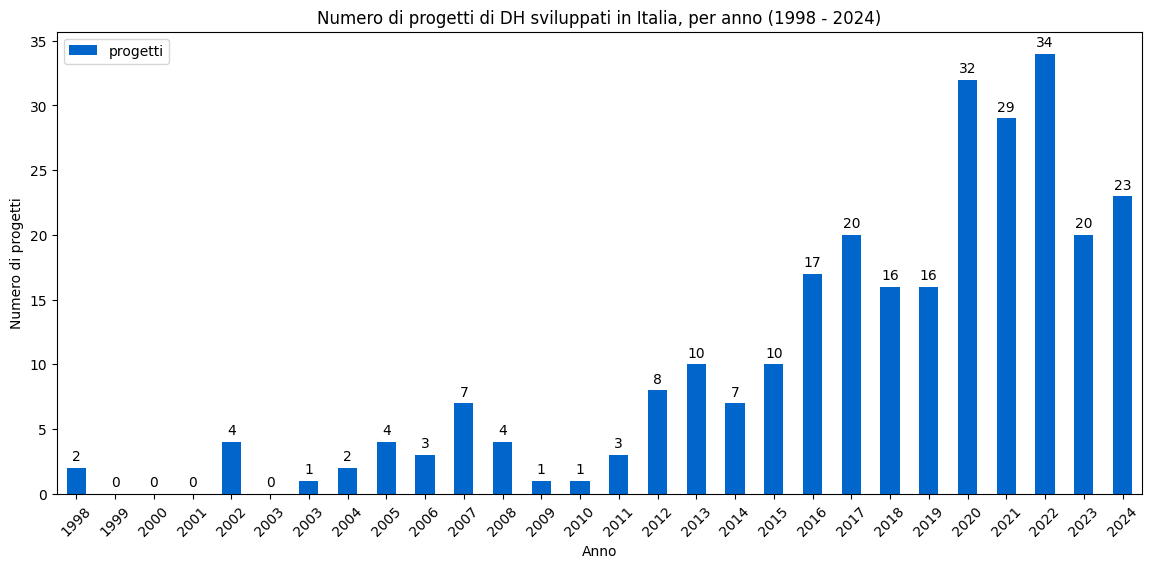

In [87]:
ax = conteggi_anno.plot(
    kind = "bar",
    # grid = True,
    color = "#0066cc",
    x = "anno",
    y = "progetti",
    xlabel="Anno",
    ylabel="Numero di progetti",
    title = "Numero di progetti di DH sviluppati in Italia, per anno (1998 - 2024)",
    figsize = (14,6),
    rot = 45
)


ax.bar_label(ax.containers[0], padding=3)

Domanda: **quali sono le istituzioni più attive in progetti di DH in Italia?** e
**quali sono i centri delle DH in Italia?**

*Mappatura dei progetti e delle istituzioni*

In [88]:
top_istituzioni = dh.groupby("istituzione").count()["progetto"].sort_values(ascending=False)

top_istituzioni = top_istituzioni.to_frame().reset_index()
top_istituzioni = top_istituzioni.sort_values(by = "progetto", ascending = False)

top_istituzioni.rename(columns = {"progetto" : "progetti"}, inplace = True)

Per individuare le istituzioni e le città più attive è necessario MAPPARE il dataset.

Sono però necessarie delle fasi preliminari:

1. **Risoluzione di possibli conflitti**

Nel dataset sono presenti numerosi progetti in **collaborazione** tra più enti e istituzioni, sia italiane che straniere.

A questo proposito abbiamo deciso di adottare i seguenti criteri:
1. Considerando che il progetto vuole studiare la situazione delle DH in Italia, sono stati eliminati i progetti che facevano capo *esclusivamente* a istituzioni straniere;
2. I progetti sviluppati da istituzioni straniere *in collaborazione* con istituzioni italiane sono stati considerati come esclusivi dell'istituzione italiana;
3. I progetti sviluppati in collaborazione tra *più* istituzioni italiane, per esigenza, sono stati considerati come esclusivi dell'istituzione *capofila* del progetto.


2. **Formattazione**

Vale a dire scegliere lo stesso nome per la stessa istituzione, ovvero portare tutte le istanze che si riferiscono a "Università La Sapienza di Roma" a questo stesso nome, e non a, per esempio, "La Sapienza" Università di Roma, ecc...


Fatto ciò, è possibile proseguire alla **mappatura** vera e propria.

Per quanto riguarda la mappatura, ovvero l'assegnazione a ciascuna istituzione di un valore per il campo "città", sono state fatte le seguenti considerazioni:
1. Per le università che hanno più sedi (es: Università di Modena e Reggio Emilia, Università del Piemonte Orientale), il progetto è considerato come svolto nella città sede del dipartimento di studi umanistici;
2. Per i centri di ricerca che hanno più sedi il progetto è stato considerato come svolto nella città della sede centrale (es: ILC-CNR ha la sede centrale a Pisa, ma un'ulteriore sede a Genova).


In [89]:
#GESTIONE DELLE COLLABORAZIONI
#Collaborazioni tra istituzioni italiane e straniere -> assegnazione all'istituzione italiana
top_istituzioni.loc[top_istituzioni["istituzione"] == "Ex Libris; Biblioteca Nazionale Centrale di Firenze", "istituzione"] = "Biblioteca Nazionale Centrale di Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Jozef Pilsudski Institute of America; Università di Sassari", "istituzione"] = "Università di Sassari"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Scuola Normale Superiore di Pisa; Bildarchiv Foto Marburg", "istituzione"] = "Scuola Normale Superiore di Pisa"
top_istituzioni.loc[top_istituzioni["istituzione"] == "The Edith O’Donnell Institute of Art History, The University of Texas at Dallas;\nCentro per la Storia dell’Arte e dell’Architettura delle Città Portuali;\nMuseo e Real Bosco di Capodimonte;\nUniversità degli Studi di Napoli Federico II;\nDuke Trinity College of Arts & Sciences;\nDigital Art History & Visual Culture Research Lab;\nNational Endowment for the Humanities;\nInternational Center of Medieval Art (ICMA).", "istituzione"] = "Centro per la Storia dell’Arte e dell’Architettura delle Città Portuali"

#I Tatti è un centro di Harvard, ma con sede fissa a Firenze, la consideriamo allora come istituzione italiana
top_istituzioni.loc[top_istituzioni["istituzione"] == "I Tatti - The Harvard University. Center For Italian Renaissance Studies; University of Bologna; Kunsthistoriches Institut in Florenz; Bibliotheca Hertziana", "istituzione"] = "I Tatti - The Harvard University. Center For Italian Renaissance Studies"

#Collaborazioni tra istituzioni italiane -> assegnazione alla prima della lista (Capofila del progetto)
top_istituzioni.loc[top_istituzioni["istituzione"] == "CNR - ISMED; Università Ca' Foscari Venezia", "istituzione"] = "CNR - ISMED"
top_istituzioni.loc[top_istituzioni["istituzione"] == "CNR-ISTI; PIN Scrl", "istituzione"] = "CNR-ISTI"
top_istituzioni.loc[top_istituzioni["istituzione"] == "CNR; Università di Bologna", "istituzione"] = "CNR"
top_istituzioni.loc[top_istituzioni["istituzione"] == "SISSA, Università di Udine, Università di Trieste", "istituzione"] = "SISSA"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Pontificia Università Gregoriana; IIT-CNR", "istituzione"] = "Pontificia Università Gregoriana"
top_istituzioni.loc[top_istituzioni["istituzione"] == "INSMLI; ANPI", "istituzione"] = "INSMLI"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ILC-CNR; Università di Pisa", "istituzione"] = "ILC-CNR"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Format – Centro Audiovisivi della Regione Emilia-Romagna; UDI", "istituzione"] = "Format – Centro Audiovisivi della Regione Emilia-Romagna"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università Ca' Foscari Venezia; Università degli studi di Udine.", "istituzione"] = "Università Ca' Foscari Venezia"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Società italiana di musicologia; Répertoire international des sources musicales; Istituto italiano per la storia della musica; Università degli studi di Roma Tor Vergata; Centro Studi sulla Cantata Italiana (CSCI).", "istituzione"] = "Società italiana di musicologia"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli Studi di Torino; ILC-CNR", "istituzione"] = "Università degli Studi di Torino"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università Ca’ Foscari Venezia; Università della Calabria;Università di Napoli Federico II; Università degli Studi di Parma ;Università degli Studi di Perugia", "istituzione"] = "Università Ca' Foscari Venezia"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli studi di Torino; Teche Rai.", "istituzione"] = "Università degli studi di Torino"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università di Bologna; Università degli studi di Torino", "istituzione"] = "Università di Bologna"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli studi di Padova; Università degli studi di Milano; Università di Siena", "istituzione"] = "Università degli studi di Padova"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli studi di Roma \"La Sapienza\"; Università Cattolica del Sacro Cuore del Sacro Cuore; Università degli studi di Torino; Università degli studi di Padova; Università degli Studi di Urbino Carlo Bo; Università degli studi della Tuscia; Università degli studi di Bergamo; Royal Netherlands Institute in Rome.", "istituzione"] = "Università degli studi di Roma \"La Sapienza\""
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli studi di Roma \"La Sapienza\"; Università Cattolica del Sacro Cuore; Università Roma Tre", "istituzione"] = "Università degli studi di Roma \"La Sapienza\""
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli studi di Roma \"La Sapienza\"; Università degli Studi di Roma \"Tor Vergata\"; Università degli Studi Roma Tre; Università degli Studi di Cassino e del Lazio Meridionale; Università degli Studi della Tuscia; CNR; ENEA; INFN", "istituzione"] = "Università degli studi di Roma \"La Sapienza\""
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università di Bologna, CNR, Università degli studi di Trento, Istituto di linguistica computazionale A. Zampolli , Accademia europea di Bolzano", "istituzione"] = "Università di Bologna"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università di Parma; Università di Bologna; Università di Pavia; Università degli studi di Roma \"La Sapienza\"; Università degli studi di Milano", "istituzione"] = "Università di Parma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università di Pisa; ILC-CNR; Università di Siena", "istituzione"] = "Università di Pisa"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università di Siena; ILC-CNR", "istituzione"] = "Università di Siena"


top_istituzioni.loc[top_istituzioni["istituzione"] == "Università Ca’ Foscari Venezia; Università di Udine", "istituzione"] = "Università di Udine"




#NORMALIZZAZIONE DEI NOMI DELLE ISTITUZIONI

#Università

#Università di Napoli Federico II
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università di Napoli Federico II", 
    "Università degli Studi di Napoli Federico II", 
    "Università Federico II di Napoli"
]), "istituzione"] = "Università di Napoli Federico II"

#Università di Padova
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università degli studi di Padova", 
    "Università degli Studi di Padova"
]), "istituzione"] = "Università di Padova"

#Università di Firenze
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università degli studi di Firenze", 
    "Università degli Studi di Firenze"
]), "istituzione"] = "Università di Firenze"

#Università di Torino
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università degli studi di Torino", 
    "Università degli Studi di Torino"
]), "istituzione"] = "Università di Torino"

#Università di Milano (Statale)
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università Statale di Milano", 
    "Università degli Studi di Milano",
    "Università di Milano"
]), "istituzione"] = "Università Statale di Milano"

#Università Cattolica del Sacro Cuore
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università Cattolica del Sacro Cuore", 
    "Università Cattolica del Sacro Cuore of Milano"
]), "istituzione"] = "Università Cattolica del Sacro Cuore"


top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli studi Modena e Reggio Emilia", "istituzione"] = "Università di Modena e Reggio Emilia"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli Studi di Salerno", "istituzione"] = "Università di Salerno"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli Studi di Udine", "istituzione"] = "Università di Udine"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli Studi di Macerata", "istituzione"] = "Università di Macerata"


#Università di Roma "La Sapienza"
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università degli studi di Roma \"La Sapienza\"", 
    "Università degli Studi di Roma 'La Sapienza'", 
    "University La Sapienza"
]), "istituzione"] = "Università \"La Sapienza\" di Roma"

#Università di Bari
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università degli studi di Bari",
    "Università degli Studi di Bari",
    "Università degli studi di Bari Aldo Moro",
    "Università degli Studi di Bari Aldo Moro"
]), "istituzione"] = "Università di Bari"

#Università Roma Tre
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Università degli Studi Roma Tre",
    "Università degli Studi Roma tre",
    "Università degli studi Roma Tre",
    "Università degli studi Roma tre",
    "Università di Roma tre",
    "Università di Roma Tre",
    "Università di Roma 3",
    "Università Roma 3",
]), "istituzione"] = "Università Roma Tre"


#Istituti CNR
top_istituzioni.loc[top_istituzioni["istituzione"].isin(["CNR-ISTI", "ISTI-CNR"]), "istituzione"] = "ISTI-CNR"
top_istituzioni.loc[top_istituzioni["istituzione"].isin(["Istituto di Linguistica Computazionale \"A. Zampolli\" (ILC-CNR)", "ILC-CNR"]), "istituzione"] = "ILC-CNR"
top_istituzioni.loc[top_istituzioni["istituzione"] == "CNR (Coordinatore centrale)", "istituzione"] = "CNR"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Istituto ILIESI - CNR", "istituzione"] = "ILIESI-CNR"

#Fondazione Bruno Kessler
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "FBK - Fondazione Bruno Kessler", 
    "FBK- Fondazione Bruno Kessler"
]), "istituzione"] = "Fondazione Bruno Kessler"

#Scuola Normale Superiore
top_istituzioni.loc[top_istituzioni["istituzione"].isin([
    "Scuola Normale Superiore", 
    "Scuola Normale Superiore di Pisa"
]), "istituzione"] = "Scuola Normale Superiore di Pisa"



#MAPPATURA

#Università

#Nella maggioranza dei casi basterà estrarre con un'espressione regolare l'ultima parola del nome dell'istituzione e inserirla come valore del campo "città" (es: "istituzione = Università di Pisa -> città = Pisa")
top_istituzioni["città"] = top_istituzioni["istituzione"].str.extract(r'\b([a-zA-Zà-ù\'-]+)\b$')[0]

#Il resto dei casi:
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università del Piemonte Orientale", "città"] = "Vercelli"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università Cattolica del Sacro Cuore", "città"] = "Milano"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università di Modena e Reggio Emilia", "città"] = "Modena"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università di Napoli Federico II", "città"] = "Napoli"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università degli Studi di Milano-Bicocca", "città"] = "Milano"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università Roma Tre", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "SISSA", "città"] = "Trieste"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Pontificia Università Gregoriana", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università del Salento", "città"] = "Lecce"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università della Tuscia", "città"] = "Viterbo"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università della Calabria", "città"] = "Cosenza"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Università della Basilicata", "città"] = "Potenza"



#CNR e Istituti di Ricerca
top_istituzioni.loc[top_istituzioni["istituzione"] == "CNR", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ISTC-CNR", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ILC-CNR", "città"] = "Pisa"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ISTI-CNR", "città"] = "Pisa"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ISPF-CNR", "città"] = "Napoli"
top_istituzioni.loc[top_istituzioni["istituzione"] == "CNR - ISMED", "città"] = "Napoli"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ILIESI-CNR", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "OVI-CNR", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Istituto di Teoria e Tecniche dell’Informazione Giuridica (ITTIG-CNR)", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ISPC-CNR", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ICAr", "città"] = "Napoli" # ICAR-CNR
top_istituzioni.loc[top_istituzioni["istituzione"] == "Istituto Nazionale di Astrofisica", "città"] = "Roma"

#Accademie, Biblioteche, Musei, Enti Pubblici
top_istituzioni.loc[top_istituzioni["istituzione"] == "Bibliotheca Hertziana", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "I Tatti - The Harvard University. Center For Italian Renaissance Studies", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Kunsthistoriches Institut in Florenz", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Accademia della Crusca", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Fondazione Bruno Kessler", "città"] = "Trento"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Centro per la Storia dell’Arte e dell’Architettura delle Città Portuali", "città"] = "Napoli"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Fondazione Enzo Franceschini", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Biblioteca Nazionale Centrale di Firenze", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Coordinamento Biblioteche Speciali e Specialistiche di Torino", "città"] = "Torino"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Biblioteca Nazionale Marciana", "città"] = "Venezia"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Biblioteca Ambrosiana", "città"] = "Milano"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Arma dei Carabinieri", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Archivio di Stato di Prato", "città"] = "Prato"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Centro del restauro di Venaria", "città"] = "Venaria Reale"
top_istituzioni.loc[top_istituzioni["istituzione"] == "SISMEL", "città"] = "Firenze"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Regione Veneto", "città"] = "Venezia"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Parco Archeologico di Siracusa", "città"] = "Siracusa"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Ministero della Cultura", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Istituto Pio Paschini per la Storia della Chiesa in Friuli", "città"] = "Udine"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Fondazione Fava", "città"] = "Bologna"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Fondazione Giannino Bassetti", "città"] = "Milano"
top_istituzioni.loc[top_istituzioni["istituzione"] == "INSMLI", "città"] = "Milano"
top_istituzioni.loc[top_istituzioni["istituzione"] == "ICCU - Istituto centrale per il catalogo unico delle biblioteche italiane e le informazioni bibliografiche", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Format – Centro Audiovisivi della Regione Emilia-Romagna", "città"] = "Bologna"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Treccani", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Società italiana di musicologia", "città"] = "Roma"
top_istituzioni.loc[top_istituzioni["istituzione"] == "Società Dantesca Italiana", "città"] = "Firenze"

#Aziende Private
top_istituzioni.loc[top_istituzioni["istituzione"] == "Èulogos", "città"] = "Torino"

#Lista delle istituzioni, fondazioni e consorzi esclusivamente esteri
istituzioni_estere = [
    "Andrew W. Mellon Foundation",
    "Duke University; Duke Databank of Documentary Papyri",
    "Consorzio di progetto OpenUP (coordinato da PPMI)",
    "Consorzio CASPAR (coordinato da STFC)",
    "Consorzio 3D-ICONS (coordinato da CWI)",
    "OpenAIRE",
    "Max Planck Institute for the History of Science",
    "Leipzig University",
    "Indiana University",
    "Università di Lubiana"
]

#Rimuoviamo dal dataframe tutte le righe in cui l'istituzione è presente in questa lista
top_istituzioni = top_istituzioni[~top_istituzioni["istituzione"].isin(istituzioni_estere)].copy()


top_istituzioni.reset_index(drop=True, inplace=True)


In [90]:
#Raggruppiamo per "istituzione" e "città" e sommiamo i progetti
top_istituzioni = top_istituzioni.groupby(["istituzione", "città"], as_index=False)["progetti"].sum()

top_istituzioni = top_istituzioni.sort_values(by="progetti", ascending=False).reset_index(drop=True)

for row in top_istituzioni.itertuples():
    print(row)
    print("---")

Pandas(Index=0, istituzione='Università di Bologna', città='Bologna', progetti=35)
---
Pandas(Index=1, istituzione='Bibliotheca Hertziana', città='Roma', progetti=20)
---
Pandas(Index=2, istituzione='Università di Pisa', città='Pisa', progetti=18)
---
Pandas(Index=3, istituzione='Università di Padova', città='Padova', progetti=14)
---
Pandas(Index=4, istituzione='Università "La Sapienza" di Roma', città='Roma', progetti=12)
---
Pandas(Index=5, istituzione="Università Ca' Foscari Venezia", città='Venezia', progetti=12)
---
Pandas(Index=6, istituzione='ILC-CNR', città='Pisa', progetti=10)
---
Pandas(Index=7, istituzione='ISTI-CNR', città='Pisa', progetti=8)
---
Pandas(Index=8, istituzione='I Tatti - The Harvard University. Center For Italian Renaissance Studies', città='Firenze', progetti=8)
---
Pandas(Index=9, istituzione='ISTC-CNR', città='Roma', progetti=7)
---
Pandas(Index=10, istituzione='Università di Siena', città='Siena', progetti=5)
---
Pandas(Index=11, istituzione='Università d

Ora raggruppiamo il dataset in base alla **città**

In [91]:
top_citta = top_istituzioni.groupby("città").sum()["progetti"]

top_citta = top_citta.to_frame()
top_citta = top_citta.sort_values(by = "progetti", ascending = False).reset_index()

top_citta

,città,progetti
0,Roma,54
1,Pisa,39
2,Bologna,37
3,Firenze,26
4,Venezia,14
5,Padova,14
6,Milano,10
7,Napoli,10
8,Torino,6
9,Catania,5


Graifico top 15 città

[Text(0, 3, '54'),
 Text(0, 3, '39'),
 Text(0, 3, '37'),
 Text(0, 3, '26'),
 Text(0, 3, '14'),
 Text(0, 3, '14'),
 Text(0, 3, '10'),
 Text(0, 3, '10'),
 Text(0, 3, '6'),
 Text(0, 3, '5'),
 Text(0, 3, '5'),
 Text(0, 3, '5'),
 Text(0, 3, '4'),
 Text(0, 3, '4'),
 Text(0, 3, '3')]

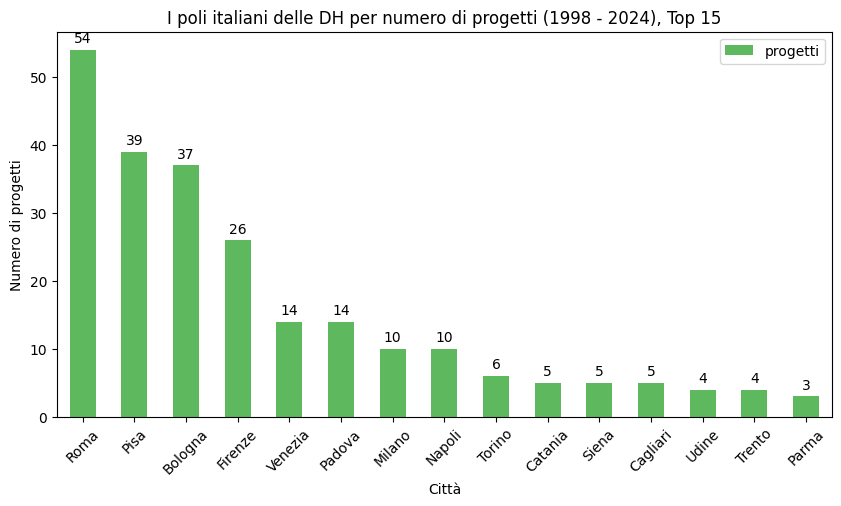

In [100]:
ax = top_citta[:15].plot(
    kind = "bar",
    x = "città",
    y = "progetti",
    color = "#5eb95e",
    # grid = True,
    title = "I poli italiani delle DH per numero di progetti (1998 - 2024), Top 15",
    xlabel = "Città",
    ylabel = "Numero di progetti",
    figsize = (10, 5),
    rot =45
    )

ax.bar_label(ax.containers[0], padding=3)

Domanda: **quali sono le 15 istituzioni più attive in progetti di DH in Italia?**

[Text(3, 0, '4'),
 Text(3, 0, '5'),
 Text(3, 0, '5'),
 Text(3, 0, '5'),
 Text(3, 0, '5'),
 Text(3, 0, '7'),
 Text(3, 0, '8'),
 Text(3, 0, '8'),
 Text(3, 0, '10'),
 Text(3, 0, '12'),
 Text(3, 0, '12'),
 Text(3, 0, '14'),
 Text(3, 0, '18'),
 Text(3, 0, '20'),
 Text(3, 0, '35')]

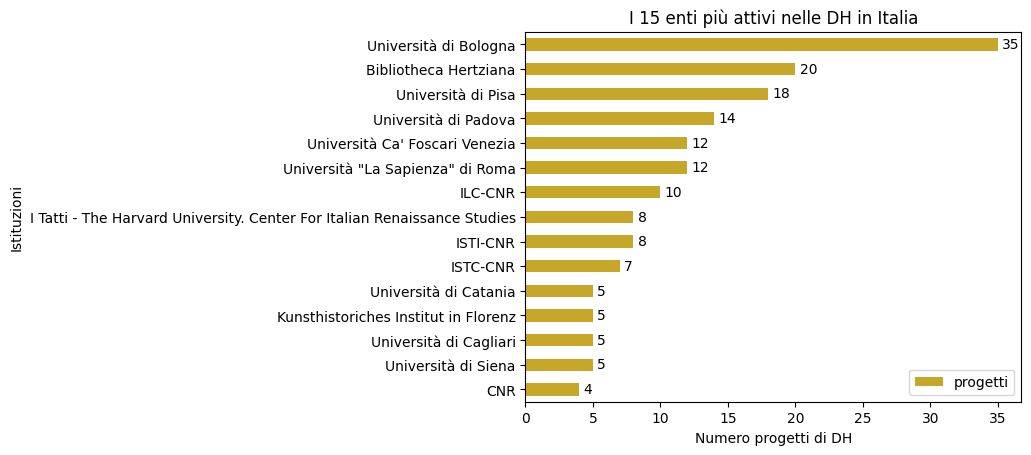

In [101]:
top_15_istituzioni = top_istituzioni[:15].sort_values(by = "progetti", ascending = True)

ax = top_15_istituzioni.plot(
    kind = "barh",
    x = "istituzione",
    xlabel = "Numero progetti di DH",
    ylabel = "Istituzioni",
    color = "#c6a72a",
    title = "I 15 enti più attivi nelle DH in Italia",
    # grid = True
)

ax.bar_label(ax.containers[0], padding=3)